# TSNE visualization of representations with/without **Replace Discriminative Task**

In [72]:
import torch
import argparse
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = '3'

import sys
sys.path.append('model')
sys.path.append('pipelines')

from model.ssl_model import MBrain
from pipelines.g_dataset_dataloader import load_dataset

In [2]:
parser = argparse.ArgumentParser(description='Training SSL model.')
# ssl-model mode setting
parser.add_argument('--ar_mode', type=str, default='LSTM',
                    help="The used AR model, including ['RNN', 'LSTM', 'GRU', 'TRANSFORMER']")
parser.add_argument('--direction', type=str, default='single',
                    help="The direction for prediction task, including ['single', 'bi', 'no']")
parser.add_argument('--graph_construct', type=str, default='sample_from_distribution',
                    choices=['sample_from_distribution', 'noGraph'],
                    help="The method for graph construction, including ['cos', 'mi', 'gumbel', 'cos_threshold']")
parser.add_argument('--graph_threshold', type=float, default=0.5,
                    help='The threshold to sample edges in graph construct module.')
# hyper parameters setting
parser.add_argument('--n_predicts', type=int, default=8,
                    help='Number of time steps in prediction task.')
parser.add_argument('--replace_ratio', type=float, default=0.15,
                    help='The ratio for replacing timestamps in replacement task.')
parser.add_argument('--hidden_dim', type=int, default=256,
                    help='The hidden dimension of model.')
parser.add_argument('--negative_samples', type=int, default=128,
                    help='The number of negative samples in prediction task.')
parser.add_argument('--kernel_size', type=int ,nargs='+', default=[4, 4, 4],
                    help='The kernel size list for encoder (Conv1d).')
parser.add_argument('--stride_size', type=int, nargs='+', default=[2, 2, 1],
                    help='The stride size list for encoder (Conv1d).')
parser.add_argument('--padding_size', type=int, nargs='+', default=[0, 0, 0],
                    help='The padding size list for encoder (Conv1d).')
# time-shift task setting
parser.add_argument('--time_shift_method', type=str, default='sample_idx',
                    choices=['predefined_score', 'predefined_idx', 'sample_idx'],
                    help='The way for time-shift measurement.')
parser.add_argument('--measure_steps', type=int, default=7,
                    help='The number of steps to measure in time-shift task.')
parser.add_argument('--time_shift_threshold', type=float, default=0.5,
                    help='The threshold to measure time-shift')
parser.add_argument('--sample_ratio', type=float, default=0.5,
                    help='The ratio of negative sample for time-shift task.')
# training details setting
parser.add_argument('--start_rep', type=int, default=20,
                    help='The epoch to start replace task.')
parser.add_argument('--start_ts', type=int, default=30,
                    help='The epoch to start time-shift task.')
parser.add_argument('--gpu', action='store_false',
                    help='Whether to use gpu.')
parser.add_argument('--batch_size', type=int, default=1,
                    help='Batch size of input data.')
parser.add_argument('--epochs', type=int, default=250,
                    help='The total number of epochs in the training stage.')
parser.add_argument('--save_step', type=int, default=10,
                    help='The number of steps to save the checkpoint.')
parser.add_argument('--early_stopping_epochs', type=int, default=10,
                    help='The number of epochs to stop training.')
parser.add_argument('--batch_num_to_step', type=int, default=8,
                    help='The number of batches to step optimizer due to gpu-memory lack.')
parser.add_argument('--learning_rate', type=float, default=2e-4,
                    help='Learning rate of SSL model in the training stage.')
parser.add_argument('--weight_decay', type=float, default=1e-6,
                    help='Weight decay of optimizer.')
parser.add_argument('--tqdm_disable', action='store_true',
                    help='Whether disable the bar of tqdm module.')
parser.add_argument('--save_dir', type=str, default='/data/caidonghong/nips22/xxx/',
                    help='The path for saving checkpoint.')
parser.add_argument('--ssl_dir', type=str, default='/data/caidonghong/nips22/MBrain_02GJX_0508/checkpoint_180.pt',
                    help='The path of SSL model to load.')
# parser.add_argument('--ssl_dir', type=str, default='/data/caidonghong/nips22/02GJX_MBrain_Delay/checkpoint_210.pt',
#                     help='The path of SSL model to load.')
# load dataset setting
parser.add_argument('--database_save_dir', type=str, default='/data/caidonghong/new_database2_no_filter/02GJX/',
                    help='The path for database_save_dir while loading database.'
                         'Patients: [01TGX, 02GJX, 03ZXY, 05ZLH, 06ZYJ]'
                         '01:125; 02:52; 03:120; 05:116; 06:101')
parser.add_argument('--data_save_dir', type=str, default='/data/eeggroup/new_data2/02GJX/',
                    help='The path for data_save_dir while loading database.')
parser.add_argument('--data_normalize', action='store_false',
                    help='Whether to normalize the data.')
parser.add_argument('--data_multi_level', action='store_true',
                    help='Whether to get multi level labels of data.')

args = parser.parse_args(args=[])

## Load Dataset

In [3]:
train_dataset, val_dataset = load_dataset(
    database_save_dir=args.database_save_dir,
    data_save_dir=args.data_save_dir,
    window_time=1,
    slide_time=1,
    data_type='ssl',
    channel_list=None,
    normalize=args.data_normalize,
    multi_level=args.data_multi_level,
    shared_encoder=True,
    n_process_loader=50,
)

train_loader = train_dataset.get_data_loader(args.batch_size, shuffle=False, num_workers=0)
val_loader = val_dataset.get_data_loader(args.batch_size, shuffle=False, num_workers=0)
print("Training Dataset: %d batches, Validation Dataset: %d batches, Batch Size: %d" %
      (len(train_loader), len(val_loader), args.batch_size))

Loading the ssl dataset...
Channel number of the patient is: 52
Total clean Segment Number:  9000
Channel class weight is:  tensor([0.0034, 0.9966])
Total valid_clean Segment Number:  1000
Channel class weight is:  tensor([0., 1.])
Training Dataset: 900 batches, Validation Dataset: 100 batches, Batch Size: 1


## Load Model (full_model & model_without_replace)

In [4]:
torch.cuda.set_device(3)

ssl_model = MBrain(
    hidden_dim=args.hidden_dim,
    channel_num=train_dataset.data_handler.channel_num,
    gcn_dim=[256],
    n_predicts=args.n_predicts,
    graph_construct=args.graph_construct,
    direction=args.direction,
    replace_ratio=args.replace_ratio,
    ar_mode=args.ar_mode,
    args = args,
)

# load checkpoint
state_dict = torch.load(str(args.ssl_dir), 'cpu')
ssl_model.load_state_dict(state_dict["BestModel"], strict=True)
ssl_model.cuda()


 -------------------- build coarse-grained correlation matrix --------------------
Loading the ssl dataset...
Channel number of the patient is: 52
Total clean Segment Number:  9000
Channel class weight is:  tensor([0.0034, 0.9966])
Total valid_clean Segment Number:  1000
Channel class weight is:  tensor([0., 1.])


MBrain(
  (gEncoder): Encoder(
    (conv1): Conv1d(1, 256, kernel_size=(4,), stride=(2,))
    (batchNorm1): ChannelNorm()
    (conv2): Conv1d(256, 256, kernel_size=(4,), stride=(2,))
    (batchNorm2): ChannelNorm()
    (conv3): Conv1d(256, 256, kernel_size=(4,), stride=(1,))
    (batchNorm3): ChannelNorm()
  )
  (gAR): ARModel(
    (baseNet): LSTM(256, 256, batch_first=True)
  )
  (fGCN): GCN(
    (conv0): GCNConv(256, 256)
  )
  (linear_out): Linear(in_features=512, out_features=256, bias=True)
  (linear_cat): Linear(in_features=256, out_features=1, bias=True)
  (Softplus): Softplus(beta=1, threshold=20)
)

In [5]:
# model with no reaplace task

ssl_model_noRep = MBrain(
    hidden_dim=args.hidden_dim,
    channel_num=train_dataset.data_handler.channel_num,
    gcn_dim=[256],
    n_predicts=args.n_predicts,
    graph_construct=args.graph_construct,
    direction=args.direction,
    replace_ratio=args.replace_ratio,
    ar_mode=args.ar_mode,
    args = args,
)

# load checkpoint
no_replace_path = '/data/caidonghong/nips22/02GJX_MBrain_Replace/checkpoint_180.pt'
state_dict = torch.load(no_replace_path, 'cpu')
ssl_model_noRep.load_state_dict(state_dict["BestModel"], strict=True)
ssl_model_noRep.cuda()


 -------------------- build coarse-grained correlation matrix --------------------
Loading the ssl dataset...
Channel number of the patient is: 52
Total clean Segment Number:  9000
Channel class weight is:  tensor([0.0034, 0.9966])
Total valid_clean Segment Number:  1000
Channel class weight is:  tensor([0., 1.])


MBrain(
  (gEncoder): Encoder(
    (conv1): Conv1d(1, 256, kernel_size=(4,), stride=(2,))
    (batchNorm1): ChannelNorm()
    (conv2): Conv1d(256, 256, kernel_size=(4,), stride=(2,))
    (batchNorm2): ChannelNorm()
    (conv3): Conv1d(256, 256, kernel_size=(4,), stride=(1,))
    (batchNorm3): ChannelNorm()
  )
  (gAR): ARModel(
    (baseNet): LSTM(256, 256, batch_first=True)
  )
  (fGCN): GCN(
    (conv0): GCNConv(256, 256)
  )
  (linear_out): Linear(in_features=512, out_features=256, bias=True)
  (linear_cat): Linear(in_features=256, out_features=1, bias=True)
  (Softplus): Softplus(beta=1, threshold=20)
)

## Get raw representations

In [76]:
# get all rep of train_loader
concat_rep = []
concat_rep_noR = []

abnormal_count = 0
for step, full_data in enumerate(tqdm(val_loader)):
    with torch.no_grad():
        batch_data, label = full_data
        
        # only consider normal data
        x, _, _ = torch.where(label != 0)
        if len(x) > 0:
            abnormal_count += 1
            continue
        
        batch_data = batch_data.cuda(non_blocking=True)
        batch_size, time_span, _, _ = batch_data.size()
        batch_data = batch_data.view(batch_size * time_span, batch_data.size(2), batch_data.size(-1))
        
        # full model
        _, after_gAR, _ = ssl_model(batch_data, train_stage=False)
        after_gAR = after_gAR.view(batch_size, time_span, after_gAR.size(1), after_gAR.size(2), after_gAR.size(-1))
        r_max = torch.max(after_gAR[:, :, :, :, :args.hidden_dim], dim=3)[0]
        r_sum = torch.sum(after_gAR[:, :, :, :, :args.hidden_dim], dim=3)
        r_mean = torch.mean(after_gAR[:, :, :, :, :args.hidden_dim], dim=3)
        concat_representation = torch.cat((r_max, r_sum, r_mean), dim=-1)
#         concat_representation = after_gAR[:, :, :, -1, :args.hidden_dim]
        concat_rep.append(concat_representation.cpu())
        
        # model without replace task
        _, after_gAR, _ = ssl_model_noRep(batch_data, train_stage=False)
        after_gAR = after_gAR.view(batch_size, time_span, after_gAR.size(1), after_gAR.size(2), after_gAR.size(-1))
        r_max = torch.max(after_gAR[:, :, :, :, :args.hidden_dim], dim=3)[0]
        r_sum = torch.sum(after_gAR[:, :, :, :, :args.hidden_dim], dim=3)
        r_mean = torch.mean(after_gAR[:, :, :, :, :args.hidden_dim], dim=3)
        concat_representation = torch.cat((r_max, r_sum, r_mean), dim=-1)
#         concat_representation = after_gAR[:, :, :, -1, :args.hidden_dim]
        concat_rep_noR.append(concat_representation.cpu())

print("threw abnormal batch num:", abnormal_count)

100%|██████████| 100/100 [00:06<00:00, 16.57it/s]

threw abnormal batch num: 0


In [77]:
train_rep = torch.cat(concat_rep, dim=0)
print(train_rep.size())
all_rep = train_rep.view(-1, train_rep.size(-2), train_rep.size(-1))
print(all_rep.size())

train_rep = torch.cat(concat_rep_noR, dim=0)
all_rep_noR = train_rep.view(-1, train_rep.size(-2), train_rep.size(-1))

torch.Size([100, 10, 52, 768])
torch.Size([1000, 52, 768])


In [8]:
# train_dataset.data_handler.brain_dict

## Sample channels and segments

In [109]:
def sample_idx(channel_num, batch_num, sample_channel_num, sample_segment_num):
    if type(sample_channel_num) != list:
        sample_channel = np.random.choice(channel_num, sample_channel_num, replace=False)
#         sample_channel = np.array([0, 11, 25])
        print('Sampled channel idx:',sample_channel)
    else:
        sample_channel = sample_channel_num
    
    sample_batch = [np.random.choice(batch_num, sample_segment_num, replace=False) for _ in range(sample_channel_num)]
    sample_batch = np.stack(sample_batch, axis=0)
    return sample_channel, sample_batch
    
def draw_tsne(full_data, noR_data, sample_label, sample_channel, perplexity=30.0):
    random_seed_pca = random.randint(0, 2**31)
    random_seed_tsne = random.randint(0, 2**31)
#     random_seed_pca=1138182894
#     random_seed_tsne=173926371
    print("Random seed of PCA and t-SNE: %d  %d"%(random_seed_pca, random_seed_tsne))
    pca = PCA(n_components=64,
              random_state=random_seed_pca)
    tsne = TSNE(n_components=2, 
                perplexity=perplexity,
    #             learning_rate=50,
                init='random',
                random_state=random_seed_tsne,
    )
    print("Before PCA, size():", full_data.shape)
    data = pca.fit_transform(full_data)
    print("After PCA, size():", data.shape)
    data = tsne.fit_transform(data)
    print("After TSNE, size():", data.shape)
    
    data_noR = pca.fit_transform(noR_data)
    data_noR = tsne.fit_transform(data_noR)
    
    plt.figure(figsize=(14, 6), dpi=100)
    plt.subplot(121)
    plt.title('t-SNE visualization of MBrain')
    for g in np.unique(sample_label):
        i = np.where(sample_label == g)
        plt.scatter(data[i,0], data[i,1], label='Chan_%d'%sample_channel[g])
    plt.legend()
#     plt.scatter(data[:, 0], data[:, 1], c=sample_label)
    
    plt.subplot(122)
    plt.title('t-SNE visualization of MBrain_noReplace')
    for g in np.unique(sample_label):
        i = np.where(sample_label == g)
        plt.scatter(data_noR[i,0], data_noR[i,1], label='Chan_%d'%sample_channel[g])
    plt.legend()
#     plt.scatter(data_noR[:, 0], data_noR[:, 1], c=sample_label)
    plt.show()
    

In [114]:
sample_channel_num = 6
sample_segment_num = 100

sample_channel, sample_batch = sample_idx(all_rep.size(1), all_rep.size(0), sample_channel_num, sample_segment_num)

sample_data_arr = []
sample_data_arr_noR = []
for i in range(sample_channel_num):
    sample_data_arr.append(all_rep[sample_batch[i]][:,sample_channel[i]])
    sample_data_arr_noR.append(all_rep_noR[sample_batch[i]][:,sample_channel[i]])
sample_data = np.stack(sample_data_arr, axis=1)
sample_data_noR = np.stack(sample_data_arr_noR, axis=1)

sample_label = np.array([i for i in range(sample_channel_num)] * sample_segment_num)

sample_data = sample_data.reshape(-1, sample_data.shape[-1])
sample_data_noR = sample_data_noR.reshape(-1, sample_data_noR.shape[-1])

# draw_tsne(sample_data, sample_data_noR, sample_label, sample_channel)
# [ 3 16  8 13 34 15]
#25 29
# [10 32 25 15 48 41]

Sampled channel idx: [10 32 25 15 48 41]


Random seed of PCA and t-SNE: 1686288032  1910224701
Before PCA, size(): (600, 768)
After PCA, size(): (600, 64)
After TSNE, size(): (600, 2)


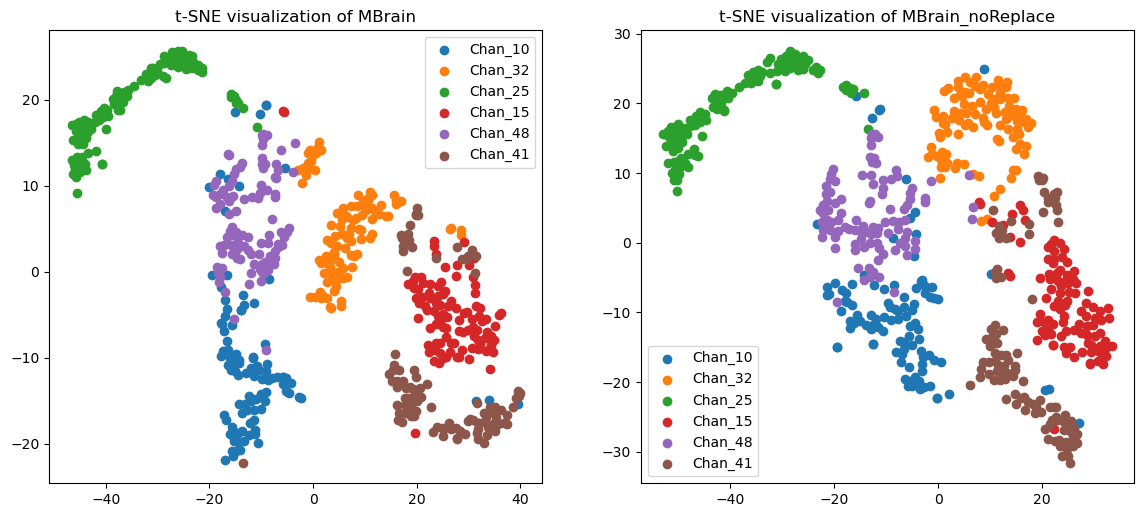

In [115]:
draw_tsne(sample_data, sample_data_noR, sample_label, sample_channel)

Random seed of PCA and t-SNE: 1632603903  1579621096
Before PCA, size(): (600, 768)
After PCA, size(): (600, 64)
After TSNE, size(): (600, 2)


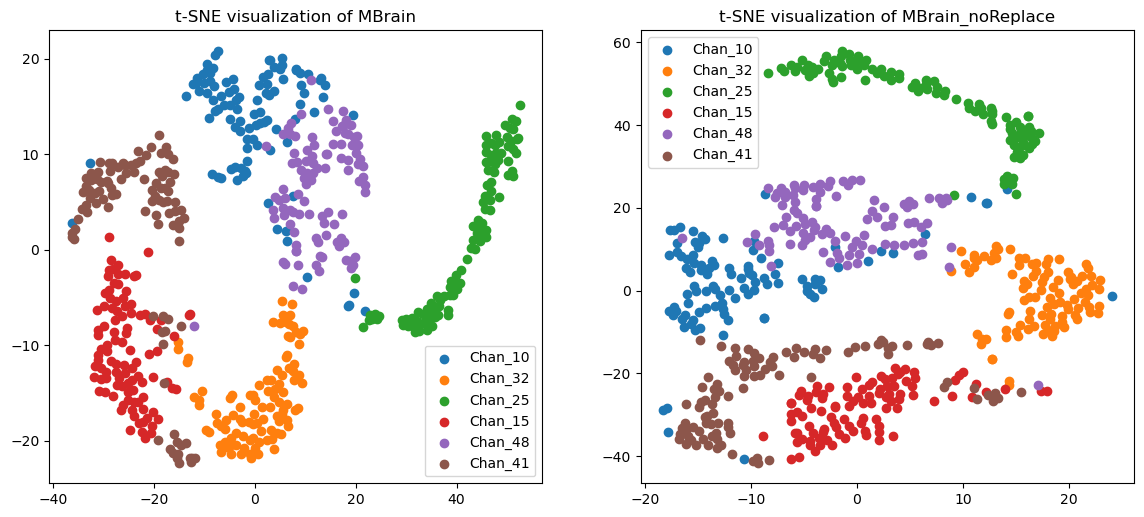

In [118]:
draw_tsne(sample_data, sample_data_noR, sample_label, sample_channel)
# [10 32 25 15 48 41]

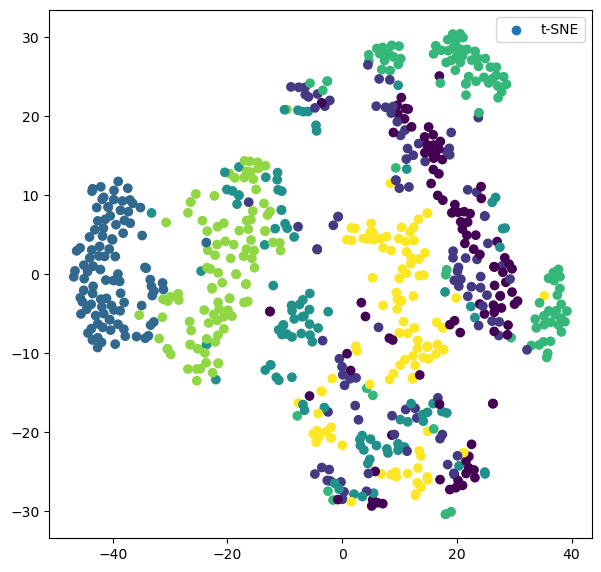

In [443]:
plt.figure(figsize=(7, 7), dpi=100)
plt.scatter(data[:, 0], data[:, 1], c=sample_label, label="t-SNE")
# plt.xlim(np.min(sample_data, axis=0)[0], np.max(sample_data, axis=0)[0])
# plt.ylim(np.min(sample_data, axis=0)[1], np.max(sample_data, axis=0)[1])
plt.legend()
plt.show()

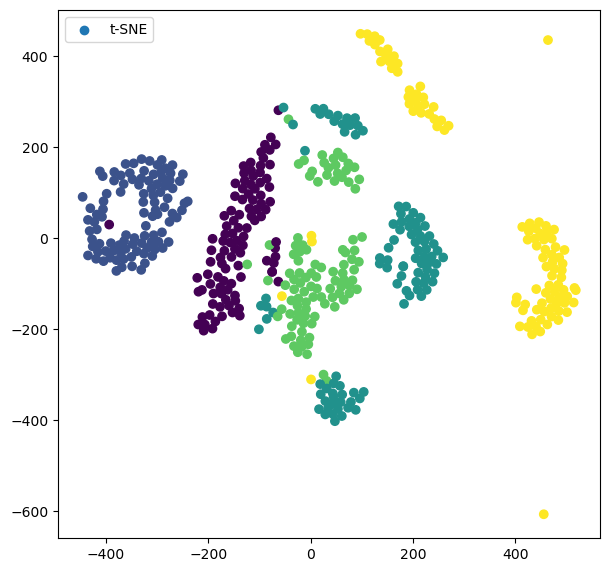

In [168]:
plt.figure(figsize=(7, 7), dpi=100)
plt.scatter(data[:, 0], data[:, 1], c=sample_label, label="t-SNE")
# plt.xlim(np.min(sample_data, axis=0)[0], np.max(sample_data, axis=0)[0])
# plt.ylim(np.min(sample_data, axis=0)[1], np.max(sample_data, axis=0)[1])
plt.legend()
plt.show()